In [2]:
import pandas as pd
import numpy as np 
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

In [8]:
with open("ml_pipeline_results.pkl", "rb") as f:
    results = pickle.load(f)


baseline_results = results["baseline_results"]
tuned_results = results["tuned_results"]
comparison_df = results["comparison_df"]
improvement_df = results["improvement_df"]
label_encoder = results["label_encoder"]
models = list(baseline_results.keys())

In [9]:
sns.set_palette("colorblind")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.titlesize": 18,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
    }
)

In [10]:
def annotate_bars(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

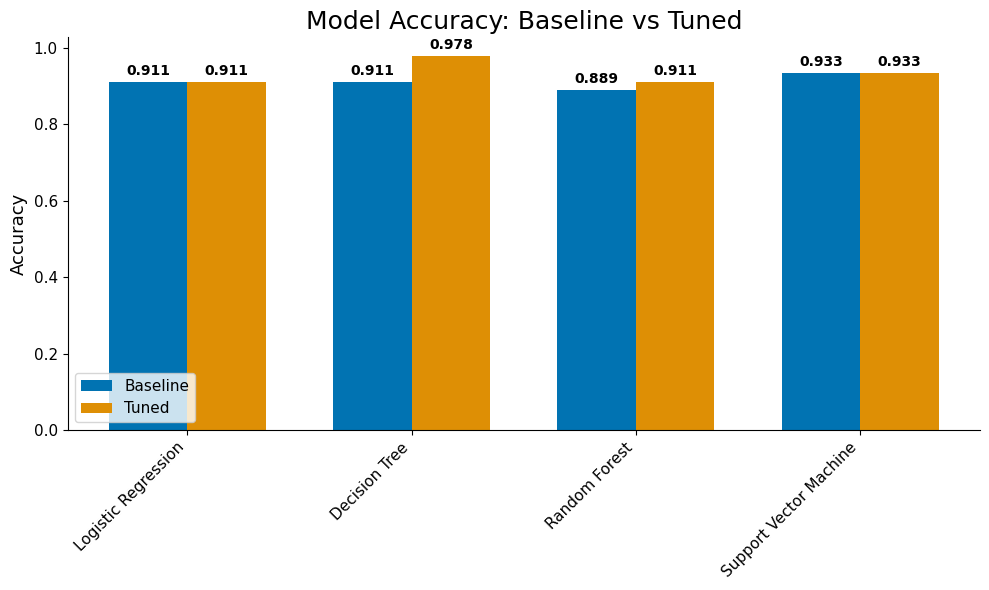

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
baseline_acc = [baseline_results[m]["accuracy"] for m in models]
tuned_acc = [tuned_results[m]["accuracy"] for m in models]
x = np.arange(len(models))
width = 0.35


bars1 = ax.bar(x - width / 2, baseline_acc, width, label="Baseline")
bars2 = ax.bar(x + width / 2, tuned_acc, width, label="Tuned")


annotate_bars(ax, bars1)
annotate_bars(ax, bars2)


ax.set_title("Model Accuracy: Baseline vs Tuned")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("viz_accuracy_comparison.png", dpi=300)

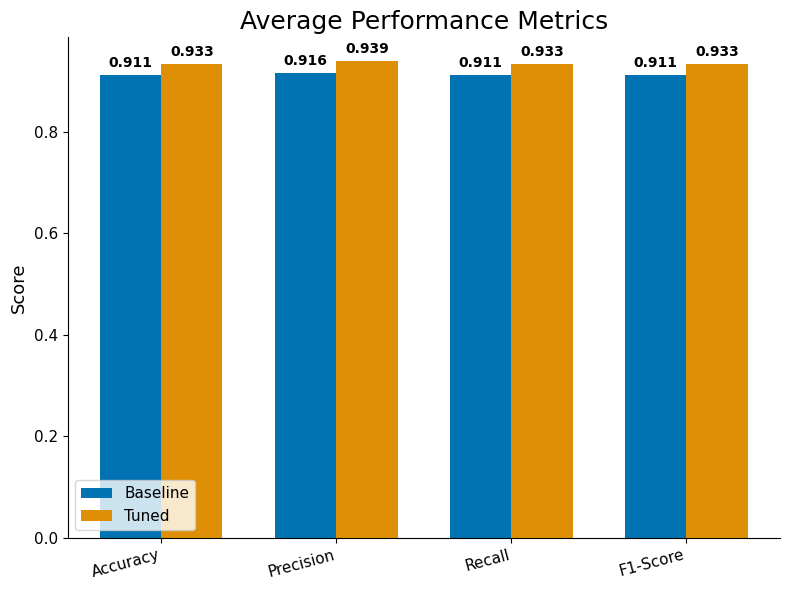

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
baseline_avg = comparison_df[comparison_df.Type == "Baseline"][metrics].mean()
tuned_avg = comparison_df[comparison_df.Type == "Tuned"][metrics].mean()


x = np.arange(len(metrics))
bars1 = ax.bar(x - width / 2, baseline_avg, width, label="Baseline")
bars2 = ax.bar(x + width / 2, tuned_avg, width, label="Tuned")


annotate_bars(ax, bars1)
annotate_bars(ax, bars2)


ax.set_title("Average Performance Metrics")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("viz_avg_metrics.png", dpi=300)


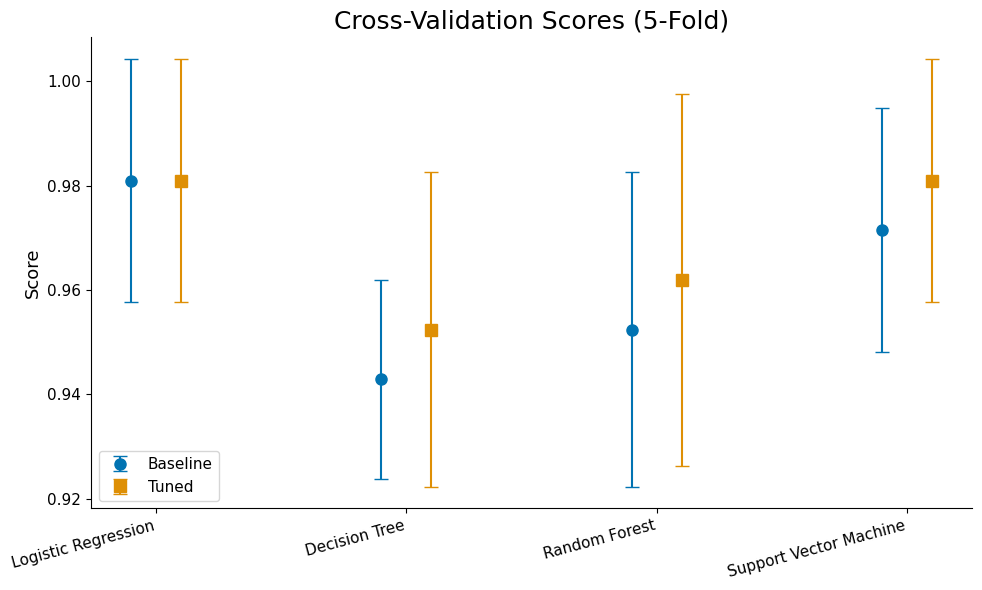

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
cv_means_base = [baseline_results[m]["cv_mean"] for m in models]
cv_stds_base = [baseline_results[m]["cv_std"] for m in models]
cv_means_tuned = [tuned_results[m]["cv_mean"] for m in models]
cv_stds_tuned = [tuned_results[m]["cv_std"] for m in models]


x = np.arange(len(models))
ax.errorbar(
    x - 0.1,
    cv_means_base,
    yerr=cv_stds_base,
    fmt="o",
    label="Baseline",
    capsize=5,
    markersize=8,
)
ax.errorbar(
    x + 0.1,
    cv_means_tuned,
    yerr=cv_stds_tuned,
    fmt="s",
    label="Tuned",
    capsize=5,
    markersize=8,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Cross-Validation Scores (5-Fold)")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()


plt.tight_layout()
plt.savefig("viz_cross_validation.png", dpi=300)



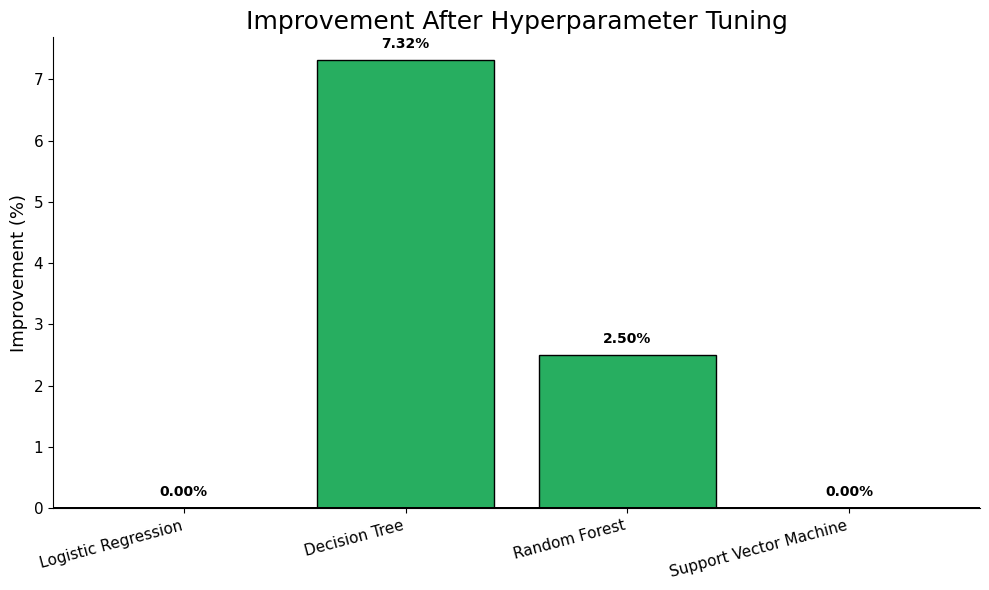

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
values = improvement_df["Improvement (%)"].values
colors = ["#27ae60" if v > 0 else "#95a5a6" for v in values]


bars = ax.bar(models, values, color=colors, edgecolor="black")


for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.2, f"{height:.2f}%",
    ha="center", fontsize=10, fontweight="bold")


    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_title("Improvement After Hyperparameter Tuning")
    ax.set_ylabel("Improvement (%)")
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=15, ha="right")
sns.despine()


plt.tight_layout()
plt.savefig("viz_improvement.png", dpi=300)

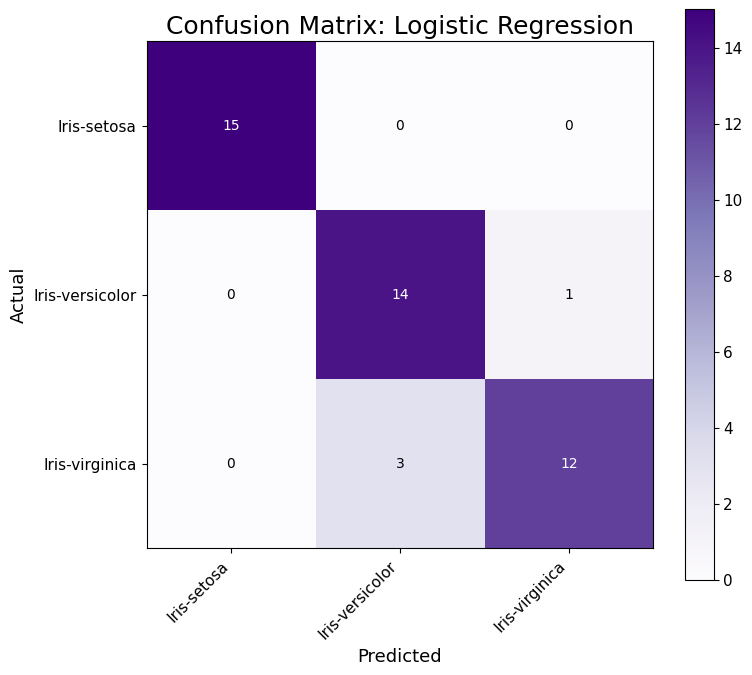

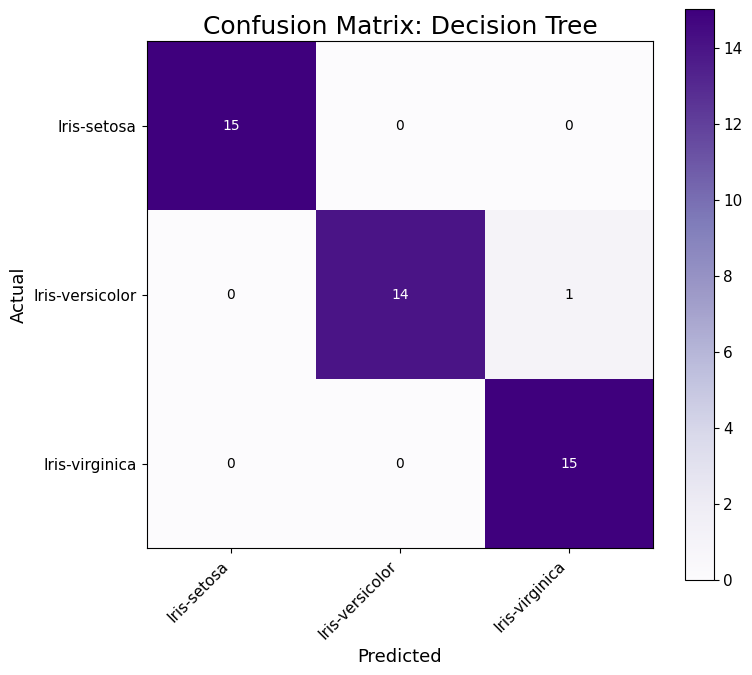

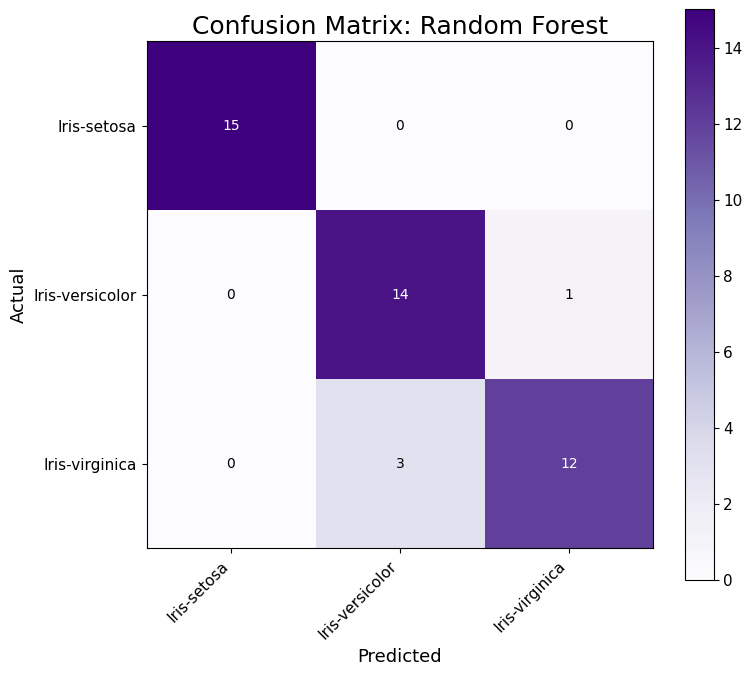

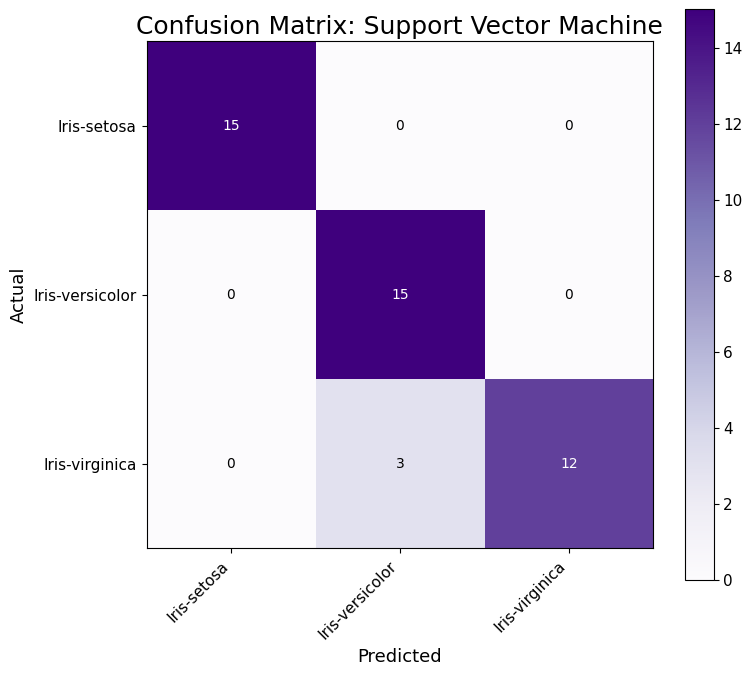

In [25]:
for model in models:
    fig, ax = plt.subplots(figsize=(8, 8))
    cm = tuned_results[model]["confusion_matrix"]
    im = ax.imshow(cm, cmap="Purples", vmin=0, vmax=cm.max())


    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
            color='white' if cm[i, j] > cm.max()/2 else 'black')


    ax.set_title(f"Confusion Matrix: {model}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
    ax.set_yticklabels(label_encoder.classes_)


    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.savefig(f"viz_confusion_matrix_{model}.png", dpi=300)